In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Sample DataFrame with a 'Data' column
data = {
    'Data': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

df = pd.DataFrame(data)

# Create new columns for the next three time steps
df['Data_t+1'] = df['Data'].shift(-1)
df['Data_t+2'] = df['Data'].shift(-2)
df['Data_t+3'] = df['Data'].shift(-3)

# Drop the rows with missing values (for the last three time steps)
df = df.dropna()

# Now, the DataFrame has the 'Data' column and three additional columns for the next three time steps
print(df)


   Data  Data_t+1  Data_t+2  Data_t+3
0    10      20.0      30.0      40.0
1    20      30.0      40.0      50.0
2    30      40.0      50.0      60.0
3    40      50.0      60.0      70.0
4    50      60.0      70.0      80.0
5    60      70.0      80.0      90.0
6    70      80.0      90.0     100.0


In [ ]:
import pandas as pd

# Load data from the Excel file
file_path = 'Temperature Dataset.xlsx'
df = pd.read_excel(file_path)

# Display the original DataFrame
#print("Original DataFrame:")
#print(df['A'])


# Min-Max normalization
min_temp = df['A'].min()
max_temp = df['A'].max()
df['A'] = (df['A'] - min_temp) / (max_temp - min_temp)

# Create time-step columns
df['B'] = df['A'].shift(-1)
df['C'] = df['A'].shift(-2)
df['D'] = df['A'].shift(-3)
df = df.dropna()

# Split data into training and testing sets
X = df[['A', 'B', 'C']].values
y = df[['D']].values
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


# Convert the DataFrame to a NumPy array
numpy_array = df.values

print(numpy_array)

[[0.2020202  0.24242424 0.27272727 0.38888889]
 [0.24242424 0.27272727 0.38888889 0.33333333]
 [0.27272727 0.38888889 0.33333333 0.24747475]
 ...
 [0.26262626 0.24242424 0.24242424 0.22727273]
 [0.24242424 0.24242424 0.22727273 0.22222222]
 [0.24242424 0.22727273 0.22222222 0.25252525]]


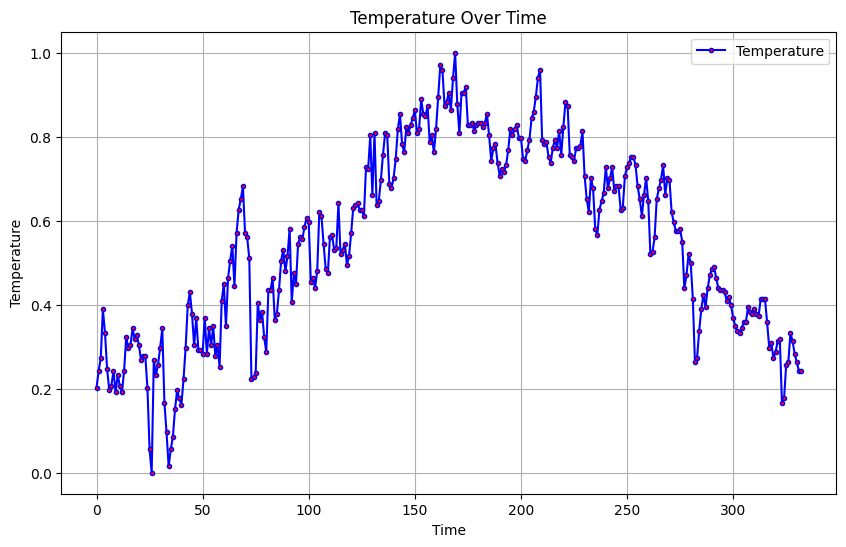

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a line chart to visualize 'Temperature'
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(df['A'], label='Temperature', marker='o', color='blue', markerfacecolor='red', markersize=3)   # Line for 'Temperature' with markers
plt.xlabel('Time')  # X-axis labelo
plt.ylabel('Temperature')  # Y-axis label
plt.title('Temperature Over Time')  # Chart title
plt.legend()  # Display legend

# Show the chart
plt.grid(True)  # Add grid lines
plt.show()

In [ ]:

class NeuralNetwork:
    def __init__(self, input_neurons, hidden_neurons, output_neurons, learning_rate=0.01, epochs=100):
        self.input_neurons = input_neurons # n0
        self.hidden_neurons = hidden_neurons # n1
        self.output_neurons = output_neurons # n2
        self.learning_rate = learning_rate
        self.epochs = epochs

        # Initialize weights
        self.w1 = np.random.uniform(-1, 1, (input_neurons, hidden_neurons)) # n0 * n1
        self.w2 = np.random.uniform(-1, 1, (hidden_neurons, output_neurons)) # n1 * n2

        # Initialize biases
        self.b1 = np.random.uniform(-1, 1, (1, hidden_neurons)) # n1
        self.b2 = np.random.uniform(-1, 1, (1, output_neurons)) # n2

        self.train_mse = []
        self.test_mse = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def pureline(self, x):
        return x;

    def pureline_derivative(self,x):
        return np.ones_like(x)

    def feedforward(self, input_data):

        self.x = input_data

        # Hidden layer calculations (including bias)
        self.net1 = np.dot(self.x, self.w1) + self.b1
        self.o1 = self.sigmoid(self.net1)

        # Output layer calculations (including bias)
        self.net2 = np.dot(self.o1, self.w2) + self.b2
        self.o2 = self.pureline(self.net2) # Linear activation for regression
        return self.o2

    def backpropagation(self, x, y_true):
        # Calculate errors
        error = y_true - self.o2


        # Update weights and biases
        self.w2 -= self.learning_rate * -1 * np.dot(self.o1.T,error.dot(np.diagflat(self.pureline_derivative(self.o2.T)))) # n1 * n2
        self.b2 -= self.learning_rate * -1 * error.dot(np.diagflat(self.pureline_derivative(self.o2.T))) # n2

        self.w1 -= self.learning_rate * -1 * np.dot(self.x.T,error.dot(np.diagflat(self.pureline_derivative(self.net2))).dot(self.w2.T).dot(np.diagflat(self.sigmoid_derivative(self.o1.T)))) # n0 * n1
        self.b1 -= self.learning_rate *-1 * error.dot(np.diagflat(self.pureline_derivative(self.net2))).dot(self.w2.T).dot(np.diagflat(self.sigmoid_derivative(self.o1.T)))  # Update hidden bias

        return np.mean(error ** 2)

    def train(self, X_train, y_train, X_test, y_test):
        for epoch in range(self.epochs):
            total_error = 0
            for i in range(len(X_train)):
                self.feedforward(X_train[i:i+1])
                total_error += self.backpropagation(X_train[i:i+1],y_train[i:i+1])

            train_mse = total_error / len(X_train)
            self.train_mse.append(train_mse)

            # Calculate test MSE at the end of each epoch
            test_predictions = self.predict(X_test)
            test_mse = np.mean((y_test.flatten() - np.array(test_predictions)) ** 2)
            self.test_mse.append(test_mse)

            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Train MSE = {train_mse}, Test MSE = {test_mse}")

    def predict(self, X):
        predictions = []
        for i in range(len(X)):
            predictions.append(self.feedforward(X[i:i+1])[0, 0])
        return predictions

Epoch 0: Train MSE = 0.23085658592528063, Test MSE = 0.09680090647519576
Epoch 10: Train MSE = 0.0247750089126664, Test MSE = 0.06655929446355459
Epoch 20: Train MSE = 0.015132985208589961, Test MSE = 0.038422092865546494
Epoch 30: Train MSE = 0.010089103592055651, Test MSE = 0.022888178160468155
Epoch 40: Train MSE = 0.0075144481414713415, Test MSE = 0.014392586484059678
Epoch 50: Train MSE = 0.006235506860650777, Test MSE = 0.009779566196439549
Epoch 60: Train MSE = 0.005612468815407523, Test MSE = 0.007264808821347721
Epoch 70: Train MSE = 0.0053108446363678745, Test MSE = 0.005871197311242553
Epoch 80: Train MSE = 0.0051629060525992376, Test MSE = 0.0050780105037149595
Epoch 90: Train MSE = 0.005087274652386316, Test MSE = 0.004611290873217418
Epoch 100: Train MSE = 0.005045384557537396, Test MSE = 0.004326537820116523
Epoch 110: Train MSE = 0.005019236720138345, Test MSE = 0.004146311998665049
Epoch 120: Train MSE = 0.005000501836081944, Test MSE = 0.004028031198847284
Epoch 130: 

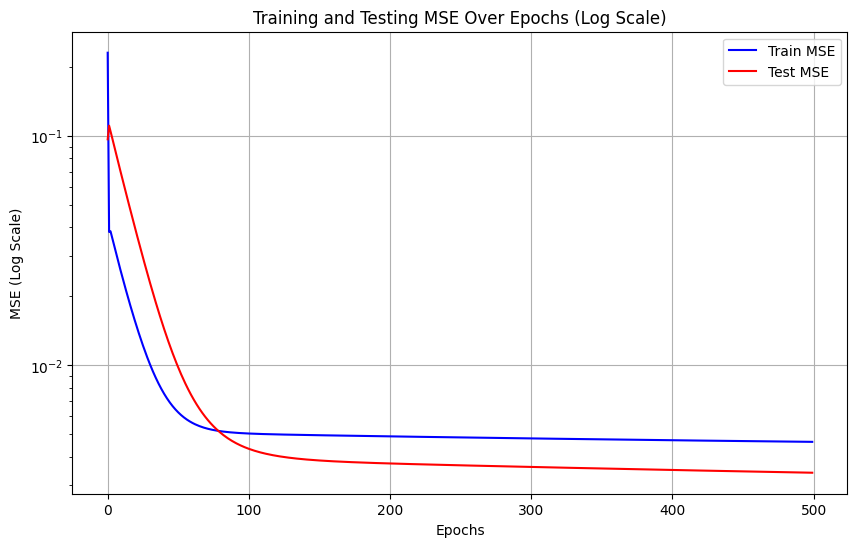

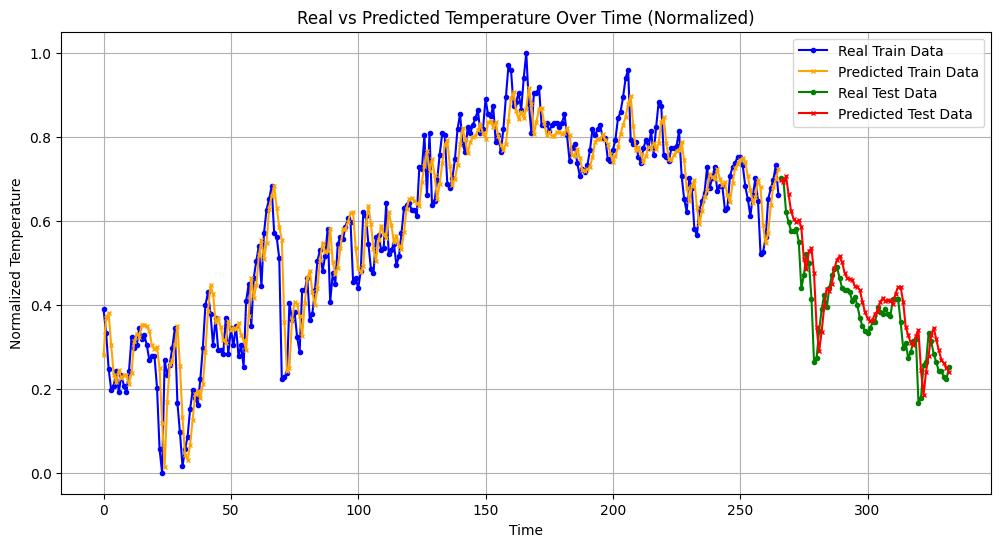

In [ ]:


# Initialize and train the neural network
learning_rate=0.005
epochs=500
hidden_neurons = 10
input_neurons = X_train.shape[1]
output_neurons = 1

nn = NeuralNetwork(input_neurons, hidden_neurons, output_neurons, learning_rate, epochs)
nn.train(X_train, y_train, X_test, y_test)

# Plot the MSE values after training
# Plot the MSE values after training with log scale on y-axis
plt.figure(figsize=(10, 6))
plt.plot(range(nn.epochs), nn.train_mse, label='Train MSE', color='blue')
plt.plot(range(nn.epochs), nn.test_mse, label='Test MSE', color='red')
plt.yscale('log')  # Use logarithmic scale for the y-axis
plt.xlabel('Epochs')
plt.ylabel('MSE (Log Scale)')
plt.title('Training and Testing MSE Over Epochs (Log Scale)')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


# Predict and plot real vs. predicted values for training and testing data
train_predictions = nn.predict(X_train)
test_predictions = nn.predict(X_test)

# Plot real vs predicted values (no denormalization needed)
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_train)), y_train.flatten(), label='Real Train Data', color='blue', marker='o', markersize=3)
plt.plot(range(len(train_predictions)), train_predictions, label='Predicted Train Data', color='orange', marker='x', markersize=3)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), label='Real Test Data', color='green', marker='o', markersize=3)
plt.plot(range(len(train_predictions), len(train_predictions) + len(test_predictions)), test_predictions, label='Predicted Test Data', color='red', marker='x', markersize=3)
plt.xlabel('Time')
plt.ylabel('Normalized Temperature')
plt.title('Real vs Predicted Temperature Over Time (Normalized)')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


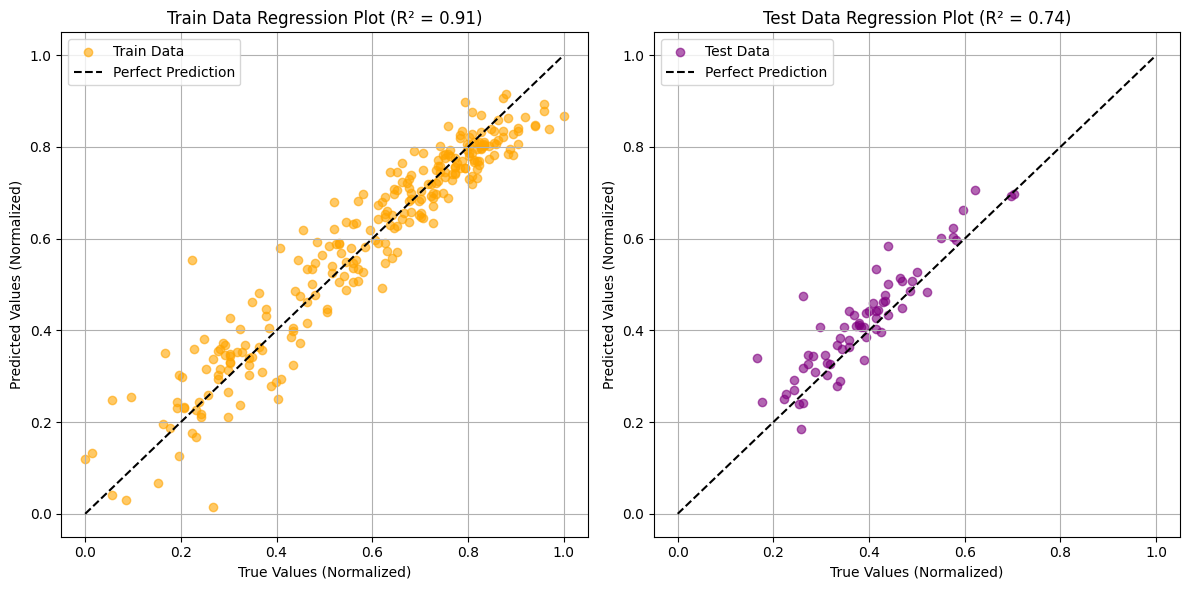

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate R² score for both training and testing data manually
mean_train = np.mean(y_train)
ss_tot_train = np.sum((y_train.flatten() - mean_train) ** 2)
ss_res_train = np.sum((y_train.flatten() - np.array(train_predictions)) ** 2)
r_squared_train = 1 - (ss_res_train / ss_tot_train)

mean_test = np.mean(y_test)
ss_tot_test = np.sum((y_test.flatten() - mean_test) ** 2)
ss_res_test = np.sum((y_test.flatten() - np.array(test_predictions)) ** 2)
r_squared_test = 1 - (ss_res_test / ss_tot_test)

# Plot 1: Real vs Predicted for Training Data
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.scatter(y_train.flatten(), train_predictions, color='orange', alpha=0.6, label='Train Data')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Perfect Prediction')  # Line y=x for reference
plt.xlabel('True Values (Normalized)')
plt.ylabel('Predicted Values (Normalized)')
plt.title(f'Train Data Regression Plot (R² = {r_squared_train:.2f})')
plt.legend(loc="upper left")
plt.grid(True)

# Plot 2: Real vs Predicted for Testing Data
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.scatter(y_test.flatten(), test_predictions, color='purple', alpha=0.6, label='Test Data')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Perfect Prediction')  # Line y=x for reference
plt.xlabel('True Values (Normalized)')
plt.ylabel('Predicted Values (Normalized)')
plt.title(f'Test Data Regression Plot (R² = {r_squared_test:.2f})')
plt.legend(loc="upper left")
plt.grid(True)

plt.tight_layout()
plt.show()
